
# Import libraries and read csv files



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
df_users = pd.read_csv('users_data.csv')
df_subscriptions = pd.read_csv('subscriptions_data.csv')

df_merged = pd.merge(df_users, df_subscriptions, on='customer_id', how='left')

Data structure

In [ ]:
print("Table 1: Users Data")
print(df_users.head())

print("\nTable 2: Subscriptions Data")
print(df_subscriptions.head())

print("\nTable 3: Merged Data")
print(df_merged.head())

Table 1: Users Data
   customer_id signup_date   country  age
0            1  2025-04-01    Norway   61
1            2  2025-06-01    Norway   50
2            3  2025-02-01  Portugal   61
3            4  2025-01-01     Spain   36
4            5  2025-04-01   Germany   75

Table 2: Subscriptions Data
   subscription_id  customer_id payment_date  status
0                1            1   2025-04-01  Active
1                2            1   2025-05-01  Active
2                3            1   2025-06-01  Active
3                4            1   2025-07-01  Active
4                5            1   2025-08-01  Active

Table 3: Merged Data
   customer_id signup_date country  age  subscription_id payment_date  status
0            1  2025-04-01  Norway   61                1   2025-04-01  Active
1            1  2025-04-01  Norway   61                2   2025-05-01  Active
2            1  2025-04-01  Norway   61                3   2025-06-01  Active
3            1  2025-04-01  Norway   61        

In [ ]:
df_sorted = df_merged.sort_values(by=["customer_id", "payment_date"])
df_latest_status = df_sorted.groupby("customer_id").last().reset_index()

In [ ]:
print(df_latest_status.head())

   customer_id signup_date   country  age  subscription_id payment_date  \
0            1  2025-04-01    Norway   61                9   2025-12-01   
1            2  2025-06-01    Norway   50               16   2025-12-01   
2            3  2025-02-01  Portugal   61               27   2025-12-01   
3            4  2025-01-01     Spain   36               39   2025-12-01   
4            5  2025-04-01   Germany   75               48   2025-12-01   

   status  
0  Active  
1  Active  
2  Active  
3  Active  
4  Active  


# Checking the churn rate

General churn rate

In [ ]:
churned = (df_latest_status['status'] == 'Churned').sum()

In [ ]:
churn_rate = churned / len(df_latest_status) * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 44.00%


Churn rate among countries

In [ ]:
country_analysis = df_latest_status.groupby('country')['status'].value_counts()
country_analysis = country_analysis.reset_index(name='count')

In [ ]:
print(country_analysis.head())

     country   status  count
0  Argentina  Churned      5
1  Argentina   Active      3
2    Austria   Active      4
3    Austria  Churned      2
4    Denmark  Churned      2


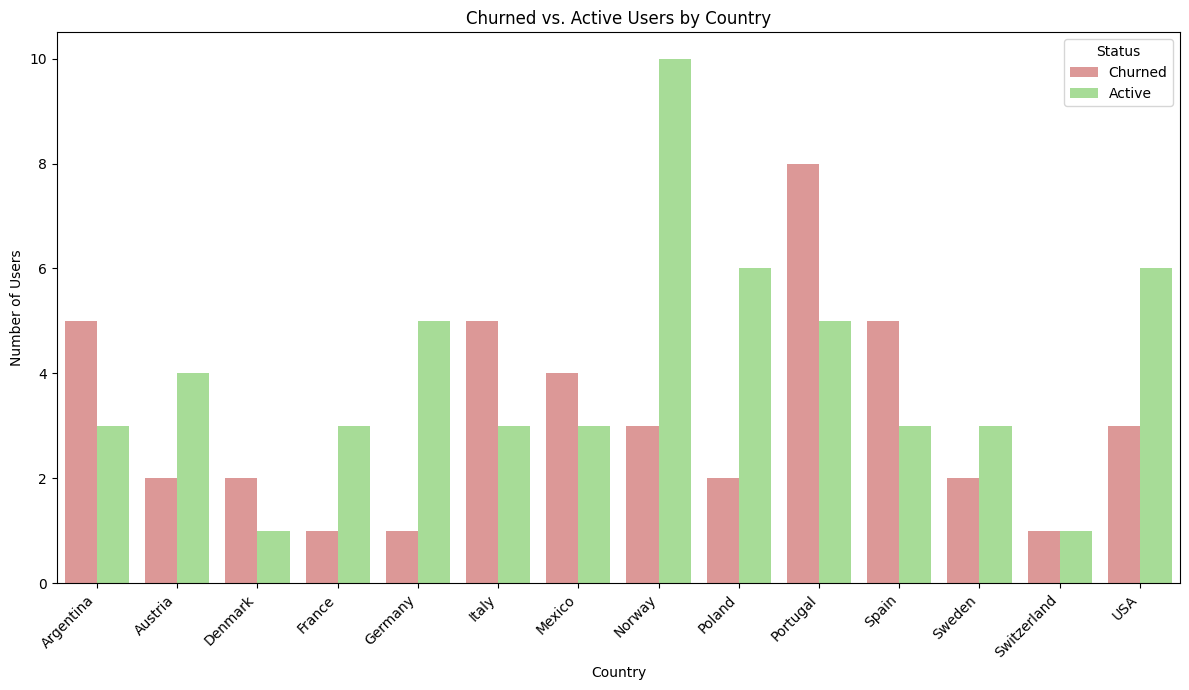

In [ ]:
country_analysis_df = country_analysis.reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=country_analysis_df, x='country', y='count', hue='status', palette=['#e88d8b', '#a1e88b'])
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.title('Churned vs. Active Users by Country')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

Most of the active users are in Norway. Countries with the least number active members are Switzerland and Denmark.

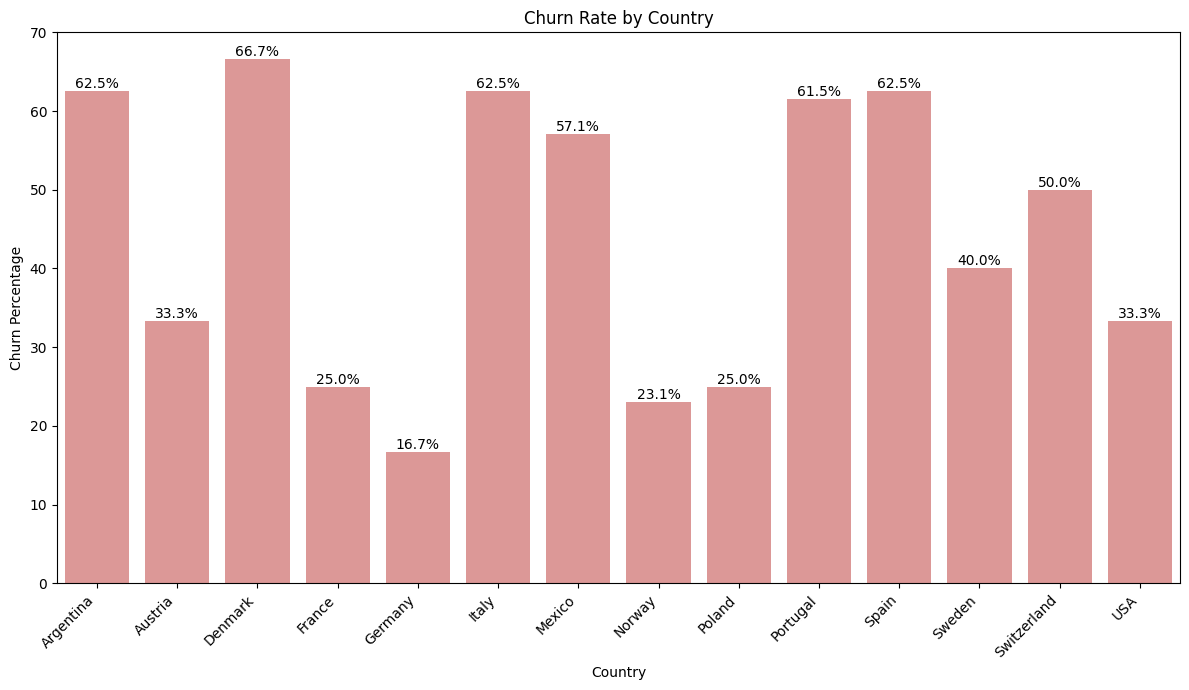

In [ ]:
# Calculate total users per country
country_total_users = country_analysis_df.groupby('country')['count'].sum().reset_index(name='total_users')

# Filter for churned users
churned_users_per_country = country_analysis_df[country_analysis_df['status'] == 'Churned']

churn_rate_df = pd.merge(churned_users_per_country, country_total_users, on='country', how='left')
churn_rate_df['count'] = churn_rate_df['count'].fillna(0)
churn_rate_df['churn_percentage'] = (churn_rate_df['count'] / churn_rate_df['total_users']) * 100

plt.figure(figsize=(12, 7))
sns.barplot(data=churn_rate_df, x='country', y='churn_percentage', color='#e88d8b')

for index, row in churn_rate_df.iterrows():
    plt.text(index, row.churn_percentage, f'{row.churn_percentage:.1f}%', color='black', ha="center", va='bottom')

# Bar plot
plt.xlabel('Country')
plt.ylabel('Churn Percentage')
plt.title('Churn Rate by Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [193]:
print(churn_rate_df.head())

   index    country   status  count  total_users  churn_percentage
0      0  Argentina  Churned      5            8         62.500000
1      3    Austria  Churned      2            6         33.333333
2      4    Denmark  Churned      2            3         66.666667
3      7     France  Churned      1            4         25.000000
4      9    Germany  Churned      1            6         16.666667


The churn-to-active customer ratio exceeds 50% in Argentina, Denmark, Italy, Mexico, Portugal, and Spain, indicating that these countries have the highest relative levels of customer attrition compared to the number of active customers.

#Churn analysis by the age

In [ ]:
age_df = df_latest_status[['customer_id', 'age', 'status']].copy()
age_df['age_group'] = pd.cut(
    age_df['age'],
    bins=[0, 25, 35, 50, 65, float('inf')],
    labels=['18-25', '26-35', '36-50', '51-65', '66+']
)
churn_table = pd.crosstab(age_df['age_group'], age_df['status'], normalize='index') * 100
churn_table = churn_table.reset_index()

print(churn_table)

status age_group     Active    Churned
0          18-25  33.333333  66.666667
1          26-35  50.000000  50.000000
2          36-50  61.538462  38.461538
3          51-65  65.384615  34.615385
4            66+  56.521739  43.478261


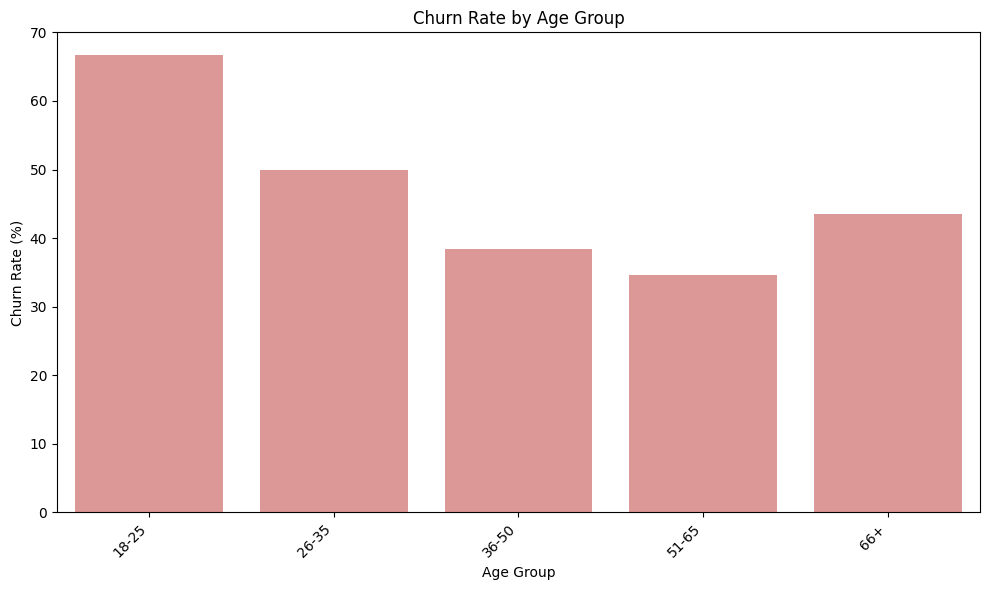

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_table, x='age_group', y='Churned', color='#e88d8b')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Age Group')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Conclusions
Analysis reveals that the 18–25 age bracket experienced the highest churn rate, with approximately 66% of users discontinuing the service in 2025. Conversely, the 36–50 and 51–65 age groups demonstrated the highest retention, recording the lowest number of cancellations.

#Analyze the length of the active status

Checking, how long every user was/has been active (all age groups included)



In [ ]:
active_only = df_merged[df_merged['status']=='Active']
length_of_active = active_only.groupby(['customer_id', 'age'])['customer_id'].count()
length_of_active = length_of_active.reset_index(name='length_active')
print(length_of_active.head())


   customer_id  age  length_active
0            1   61              9
1            2   50              7
2            3   61             11
3            4   36             12
4            5   75              9


In [ ]:
#mean of the active time (in months)
mean_of_active = length_of_active['length_active'].mean()
print(mean_of_active)

7.123595505617978


In [ ]:
#median of the active time (in months)
median_of_active = length_of_active['length_active'].median()
print(median_of_active)

7.0


In [ ]:
#standard deviation of active time (in months)
std_of_active = length_of_active['length_active'].std()
print(std_of_active)

3.505904839498063


<Axes: xlabel='length_active', ylabel='Count'>

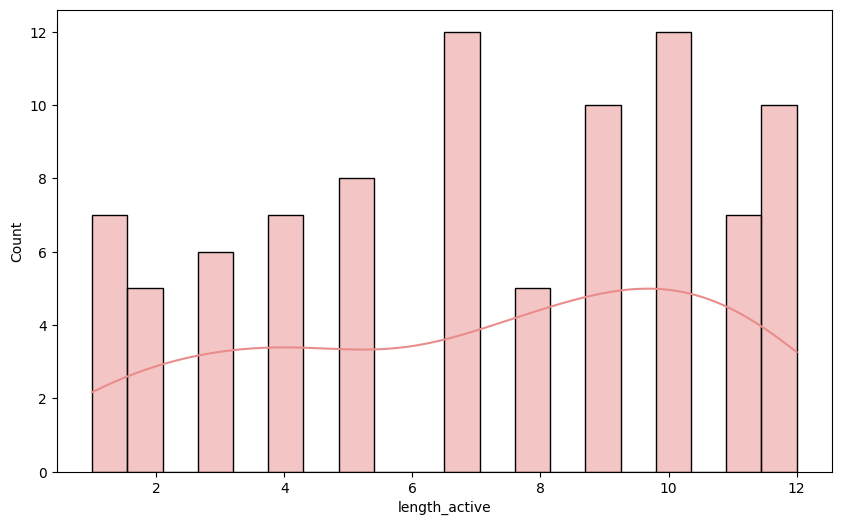

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=length_of_active, x='length_active', bins=20, kde=True, color='#e88d8b')

## Conclusions

*   The majority of users have been using the service for more than 6 months.
*   KDE analysis reveals a left-skewed distribution, indicating that most active customers are key, loyal users.


## Checking the status for each age group

In [ ]:
length_of_active_age = length_of_active[['customer_id', 'length_active']].copy()
length_of_active_age['age_group'] = pd.cut(
    length_of_active['age'],
    bins=[0, 25, 35, 50, 65, float('inf')],
    labels=['18-25', '26-35', '36-50', '51-65', '66+']
)

print(length_of_active_age.head())

   customer_id  length_active age_group
0            1              9     51-65
1            2              7     36-50
2            3             11     51-65
3            4             12     36-50
4            5              9       66+


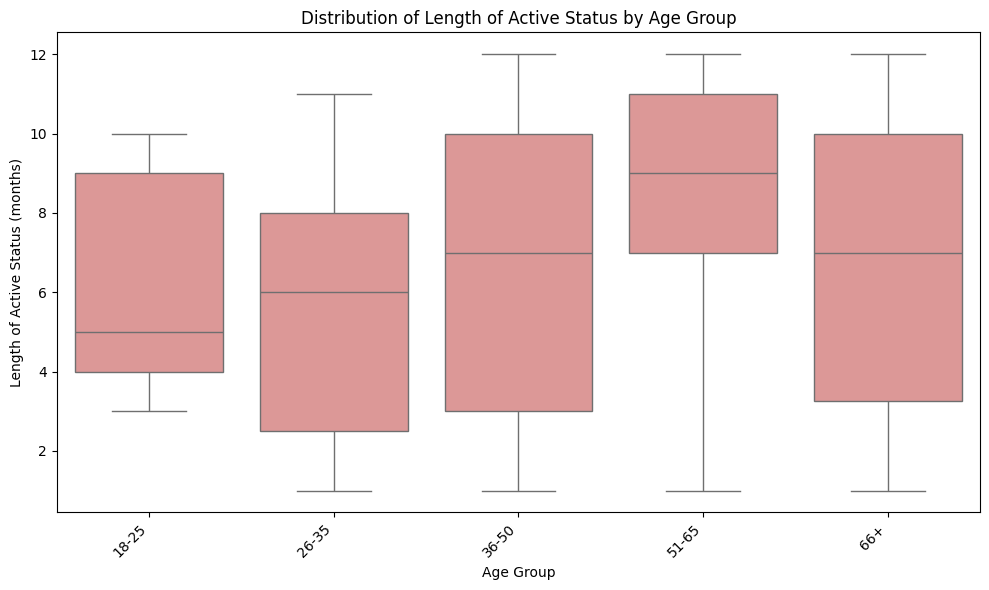

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=length_of_active_age, x='age_group', y='length_active', color='#e88d8b')
plt.xlabel('Age Group')
plt.ylabel('Length of Active Status (months)')
plt.title('Distribution of Length of Active Status by Age Group')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Conclusions


*  **18-25**

    Younger users exhibit shorter active tenure and are less likely to reach the maximum subscription duration of 11–12 months compared to older age groups.
*   **26-35, 36-50**

    There is substantial variance within this group, which comprises a balanced mix of newer users (with 3 to 5 months of tenure) and long-term subscribers.

*   **51-65**

    As many as 75% of users have been using the service for at least 7 months, representing the most stable customer segment with the lowest risk of early churn.





#Churn rate along the months

In [ ]:
months = ['Jan','Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

In [ ]:
number_churns_per_month = df_subscriptions[df_subscriptions['status'] == 'Churned'].groupby('payment_date').size()
number_churns_per_month = number_churns_per_month.reset_index(name='churns_number')
print(number_churns_per_month.head())

  payment_date  churns_number
0   2025-01-01              2
1   2025-02-01              3
2   2025-03-01              2
3   2025-04-01              5
4   2025-05-01              9


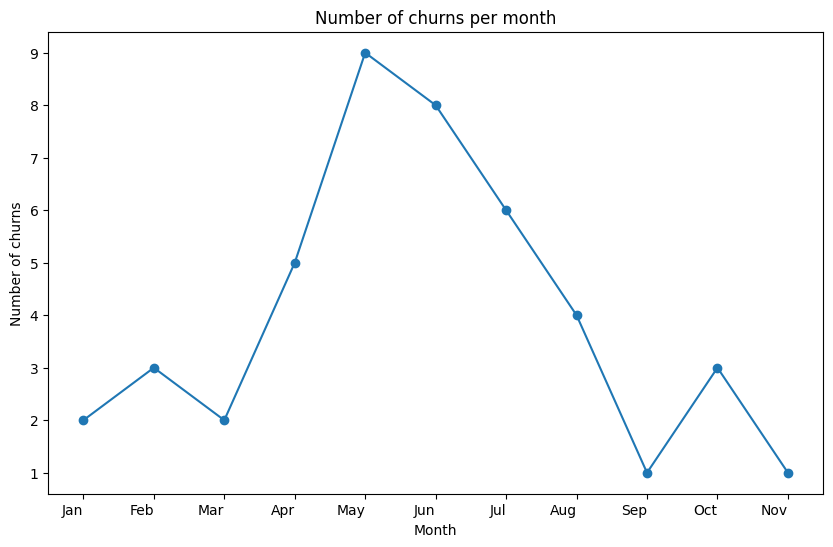

In [ ]:
#line plot with the
plt.figure(figsize=(10, 6))
plt.title('Number of churns per month')
plt.xlabel('Month')
plt.ylabel('Number of churns')
plt.xticks(range(len(months)), months, ha='right')
plt.plot(number_churns_per_month['payment_date'], number_churns_per_month['churns_number'], marker='o')
plt.show()

* There is a visible **increase** in the churns number during the
period **2025-03-01 to 2025-05-01**.

* There is also a visible **drop** in the number of churns during the period **2025-06-01 to 2025-09-01**

* Months with the highest number of churns: **May** (9)

* Months with the least number of churns: **September, November** (1)


#Active members over time

In [ ]:
number_active_per_month = df_subscriptions[df_subscriptions['status'] == 'Active'].groupby('payment_date').size()
number_active_per_month = number_active_per_month.reset_index(name='number_active')
print(number_active_per_month.head())



  payment_date  number_active
0   2025-01-01             17
1   2025-02-01             29
2   2025-03-01             47
3   2025-04-01             55
4   2025-05-01             60


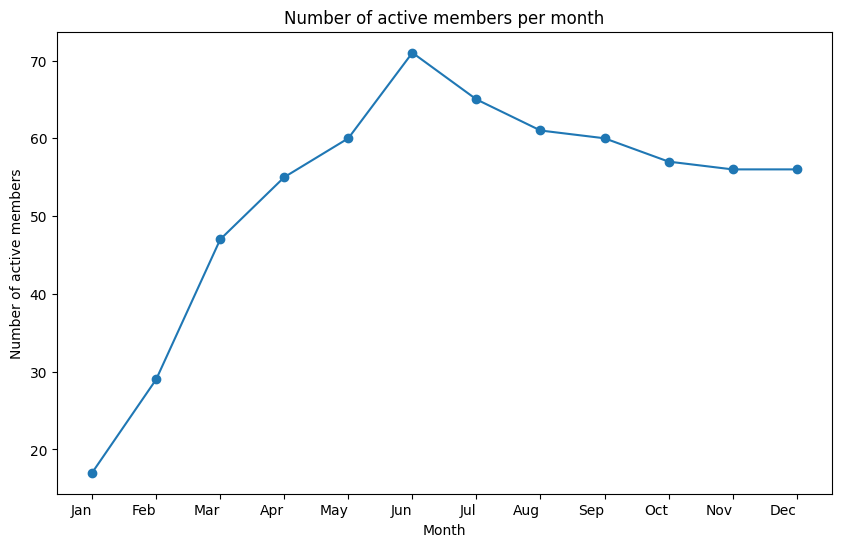

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Number of active members per month')
plt.xlabel('Month')
plt.ylabel('Number of active members')
plt.plot(number_active_per_month['payment_date'], number_active_per_month['number_active'], marker='o')
plt.xticks(range(len(months)), months, ha='right')
plt.show()


The active user count increases sharply from January to June, peaking in June at 70 active users. It then declines and stabilizes between July and December, maintaining a consistent level of 56 to 65 active users throughout this period.

#Comparison of the active members and the number of churns

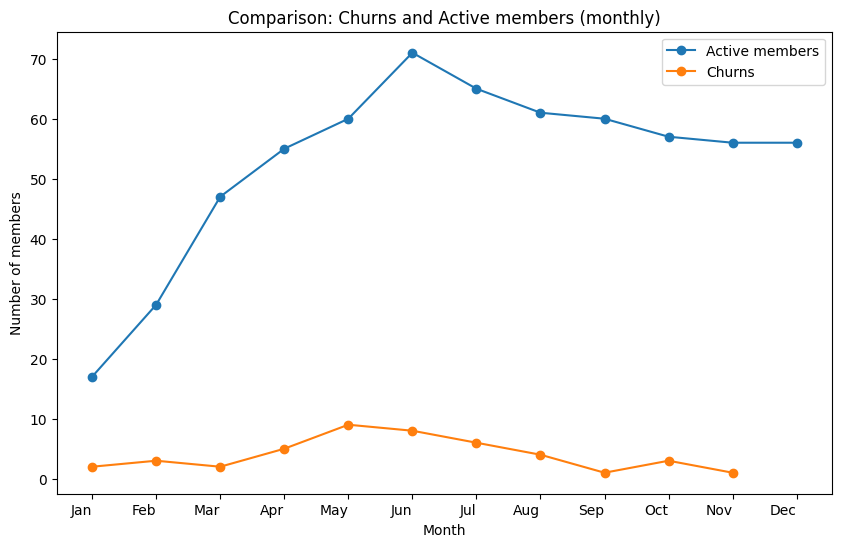

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Comparison: Churns and Active members (monthly)')
plt.xlabel('Month')
plt.ylabel('Number of members')
plt.plot(number_active_per_month['payment_date'], number_active_per_month['number_active'], marker='o', label = 'Active members')
plt.plot(number_churns_per_month['payment_date'], number_churns_per_month['churns_number'], marker='o', label = 'Churns')
plt.legend()
plt.xticks(range(len(months)), months, ha='right')
plt.show()

## **Key Observations:**

* **Proportional Relationship:** There is a strong correlation between active user count and churn rate—churn reaches its peak in May and June, mirroring the highest period of active membership (~70 users).

* **Post-Peak Stabilization:** Following the mid-year peak, active membership remains relatively stable around 55–65 members, while churn declines to its lowest levels between September and November.

## **Key Takeaway / Conclusion:**
The increase in churn during peak months suggests that churn is largely volume-driven (more users naturally result in more cancellations) rather than caused by a sudden drop in customer satisfaction later in the year. However, investigating why cancellations peak around May–June could help improve mid-year retention strategies.

#Importing df to csv

In [194]:
df_merged.to_csv('df_merged.csv', index=False)
df_latest_status.to_csv('df_latest_status.csv', index=False)
length_of_active.to_csv('length_of_active.csv', index=False)
number_churns_per_month.to_csv('number_churns_per_month.csv', index=False)
number_active_per_month.to_csv('number_active_per_month.csv', index=False)
length_of_active_age.to_csv('length_of_active_age.csv', index=False)
churn_table.to_csv('churn_table.csv', index=False)
churn_rate_df.to_csv('churn_rate_df.csv', index=False)
country_analysis_df.to_csv('country_analysis_df.csv', index=False)

#